# Machine Learning Analysis

This notebook uses the cleaned event-level dataset produced in
`01_data_cleaning_and_eda.ipynb`. It compares Logistic Regression,
Random Forest, and Gradient Boosting models and evaluates model
performance using accuracy, precision, recall, F1-score, ROC-AUC,
and PR-AUC.

## Machine Learning Model 1: Logistic Regression Baseline

In this section, I build the first machine learning model to predict whether a cleanup event is a high-unusual-debris event.

The target variable is `high_unusual_event`.

The model only uses pre-cleanup or near-pre-cleanup features, such as year, month, location, cleanup type, people, distance, and area. It does not use `Total Items Collected`, `unusual_debris_count`, or `unusual_share`, because those variables are only known after the cleanup and would cause data leakage.

The first model is Logistic Regression, which serves as a simple and interpretable baseline.

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# Load the cleaned modeling dataset produced by the first notebook
df = pd.read_csv("coastal_cleanup_model_data_2015_2026.csv")

# Create a separate copy for machine-learning analysis
ml_data = df.copy()

# Define the target variable
target = "high_unusual_event"

print("Dataset shape:", ml_data.shape)
print("\nColumns:")
print(ml_data.columns.tolist())

# Features that can be used before or near the cleanup event
# We exclude Environment for the first model because it has too many missing values.
numeric_features = [
    "year",
    "month",
    "hurricane_season",
    "Latitude",
    "Longitude",
    "People",
    "Distance km",
    "Area km"
]

categorical_features = [
    "state_name",
    "zone_name",
    "Cleanup Type"
]
#combing them into same list
features = numeric_features + categorical_features

# Create X and y
X = ml_data[features].copy()
y = ml_data[target].copy()

print("X shape:")
print(X.shape)

print("\ny shape:")
print(y.shape)

print("\nFeatures used:")
print(features)

print("\nTarget distribution:")
print(y.value_counts(normalize=True))

Dataset shape: (131909, 19)

Columns:
['Cleanup ID', 'Cleanup Date', 'Total Items Collected', 'unusual_debris_count', 'unusual_share', 'source_year', 'year', 'month', 'hurricane_season', 'zone_name', 'state_name', 'Latitude', 'Longitude', 'Cleanup Type', 'Environment', 'People', 'Distance km', 'Area km', 'high_unusual_event']
X shape:
(131909, 11)

y shape:
(131909,)

Features used:
['year', 'month', 'hurricane_season', 'Latitude', 'Longitude', 'People', 'Distance km', 'Area km', 'state_name', 'zone_name', 'Cleanup Type']

Target distribution:
high_unusual_event
0    0.749721
1    0.250279
Name: proportion, dtype: float64


In [61]:
#check missing values in selected features

missing_rates = X.isna().mean().sort_values(ascending=False)
print("Missing rate in selected features:")
print(missing_rates)

Missing rate in selected features:
state_name          0.002752
zone_name           0.002123
People              0.001357
Distance km         0.000045
year                0.000000
month               0.000000
hurricane_season    0.000000
Latitude            0.000000
Longitude           0.000000
Area km             0.000000
Cleanup Type        0.000000
dtype: float64


In [62]:
#split data into training set and test set


#here we split 80% of data to be training set and the rest 20% to be test set after model is complete
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set size:")
print(X_train.shape)

print("\nTest set size:")
print(X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Training set size:
(105527, 11)

Test set size:
(26382, 11)

Training target distribution:
high_unusual_event
0    0.749723
1    0.250277
Name: proportion, dtype: float64

Test target distribution:
high_unusual_event
0    0.749716
1    0.250284
Name: proportion, dtype: float64


In [63]:


# for numeric features, i fill missing values using median and standardize numeric scale
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# for categorical features, i fill missing values using "Unknown" and 
#convert categories into dummy variables using one-hot encoding 

try:
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ])
except TypeError:
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=True))
    ])

# Combine numeric and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [64]:
#build the logistic model
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


In [65]:
#Training the logistic model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [66]:
# evaluate Logistic Regression model

# Predict class labels: 0 or 1
y_pred = logistic_model.predict(X_test)

# Predict probability of class 1
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("PR-AUC:", average_precision_score(y_test, y_pred_proba))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7306117807596089
Precision: 0.47573189522342063
Recall: 0.7481447826745419
F1-score: 0.5816212397715901
ROC-AUC: 0.8028589417531388
PR-AUC: 0.5620714017928182

Confusion matrix:
[[14335  5444]
 [ 1663  4940]]

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80     19779
           1       0.48      0.75      0.58      6603

    accuracy                           0.73     26382
   macro avg       0.69      0.74      0.69     26382
weighted avg       0.79      0.73      0.75     26382



### Logistic Regression baseline evaluation

This cell evaluates the Logistic Regression baseline model on the test set.  
The model achieves a ROC-AUC of about 0.80, suggesting that it can meaningfully distinguish high-unusual-debris events from normal cleanup events.

The recall for high-unusual events is relatively high, meaning the model identifies many of the true high-unusual events. However, precision is lower, which means the model also produces some false positives. This tradeoff is expected because the model uses `class_weight="balanced"` to give more weight to the minority class.

Overall, Logistic Regression provides a useful and interpretable baseline. The next step is to compare it with tree-based models such as Random Forest and Gradient Boosting.

## Machine Learning Model 2: Random Forest

The second model is Random Forest, a tree-based machine learning model.  
Unlike Logistic Regression, Random Forest can capture nonlinear relationships and interactions among features.

For example, it can learn patterns such as certain states, months, and cleanup types being jointly associated with higher high-unusual-debris risk.

This model is used to compare against the Logistic Regression baseline.

In [67]:
# Cell 29: Create a reusable evaluation function

def evaluate_model(model_name, model, X_test, y_test):

    
    # Predict class labels: 0 or 1
    y_pred = model.predict(X_test)
    
    # Predict probability of class 1
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Store metrics in a dictionary
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_pred_proba),
        "pr_auc": average_precision_score(y_test, y_pred_proba)
    }
    
    print("Model:", model_name)
    print("Accuracy:", results["accuracy"])
    print("Precision:", results["precision"])
    print("Recall:", results["recall"])
    print("F1-score:", results["f1_score"])
    print("ROC-AUC:", results["roc_auc"])
    print("PR-AUC:", results["pr_auc"])
    
    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification report:")
    print(classification_report(y_test, y_pred))
    
    return results

In [68]:
# Cell 30: Save Logistic Regression evaluation results

model_results = []

logistic_results = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_test,
    y_test
)

model_results.append(logistic_results)

Model: Logistic Regression
Accuracy: 0.7306117807596089
Precision: 0.47573189522342063
Recall: 0.7481447826745419
F1-score: 0.5816212397715901
ROC-AUC: 0.8028589417531388
PR-AUC: 0.5620714017928182

Confusion matrix:
[[14335  5444]
 [ 1663  4940]]

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80     19779
           1       0.48      0.75      0.58      6603

    accuracy                           0.73     26382
   macro avg       0.69      0.74      0.69     26382
weighted avg       0.79      0.73      0.75     26382



In [69]:
# Cell 31: Build Random Forest model

from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [70]:
# Cell 32: Train Random Forest model

random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [71]:
# Cell 33: Evaluate Random Forest model

random_forest_results = evaluate_model(
    "Random Forest",
    random_forest_model,
    X_test,
    y_test
)

model_results.append(random_forest_results)

Model: Random Forest
Accuracy: 0.7363353801834585
Precision: 0.4834069756510294
Recall: 0.7787369377555656
F1-score: 0.5965197215777263
ROC-AUC: 0.8149657685316125
PR-AUC: 0.5900263058686659

Confusion matrix:
[[14284  5495]
 [ 1461  5142]]

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.72      0.80     19779
           1       0.48      0.78      0.60      6603

    accuracy                           0.74     26382
   macro avg       0.70      0.75      0.70     26382
weighted avg       0.80      0.74      0.75     26382



In [72]:
# Cell 34: Compare model performance

model_comparison = pd.DataFrame(model_results)

display(model_comparison)

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression,0.730612,0.475732,0.748145,0.581621,0.802859,0.562071
1,Random Forest,0.736335,0.483407,0.778737,0.596520,0.814966,0.590026


### Random Forest evaluation

The Random Forest model performs slightly better than the Logistic Regression baseline across all major metrics. It improves recall, F1-score, ROC-AUC, and PR-AUC, suggesting that tree-based models can capture nonlinear relationships and interactions among location, time, cleanup type, and cleanup effort features.

The recall for high-unusual-debris events is about 0.78, meaning the model identifies most of the true high-unusual events in the test set. Precision is still moderate, which means the model also produces some false positives. This tradeoff is acceptable for a risk-screening model, where identifying potentially high-risk cleanup events is important.

Overall, Random Forest is currently the better-performing model compared with Logistic Regression.

## Machine Learning Model 3: Gradient Boosting

The third model is Gradient Boosting, another tree-based machine learning model.  
Gradient Boosting builds trees sequentially, where each new tree tries to correct errors made by previous trees.

This model is included to test whether a boosting approach can improve prediction performance beyond Logistic Regression and Random Forest.

In [73]:
# Cell 35A: Build a dense preprocessor for Gradient Boosting


# Numeric preprocessing
numeric_transformer_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
# For Gradient Boosting, we use dense output instead of sparse output.
try:
    categorical_transformer_dense = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
except TypeError:
    categorical_transformer_dense = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
    ])

# Combine numeric and categorical preprocessing
preprocessor_dense = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer_dense, numeric_features),
        ("categorical", categorical_transformer_dense, categorical_features)
    ]
)

print("Dense preprocessor created successfully.")

Dense preprocessor created successfully.


In [74]:
# Cell 35B: Build Gradient Boosting model with dense preprocessing

from sklearn.ensemble import HistGradientBoostingClassifier

gradient_boosting_model = Pipeline(steps=[
    ("preprocessor", preprocessor_dense),
    ("model", HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        class_weight="balanced",
        random_state=42
    ))
])

print("Gradient Boosting pipeline created successfully.")

Gradient Boosting pipeline created successfully.


In [75]:
# Cell 36: Train Gradient Boosting model

gradient_boosting_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [76]:
# Cell 37: Evaluate Gradient Boosting model

gradient_boosting_results = evaluate_model(
    "Gradient Boosting",
    gradient_boosting_model,
    X_test,
    y_test
)

model_results.append(gradient_boosting_results)

Model: Gradient Boosting
Accuracy: 0.7463801076491547
Precision: 0.49583885000945715
Recall: 0.7940330152960775
F1-score: 0.6104674855911976
ROC-AUC: 0.8415574331712998
PR-AUC: 0.637561049666666

Confusion matrix:
[[14448  5331]
 [ 1360  5243]]

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81     19779
           1       0.50      0.79      0.61      6603

    accuracy                           0.75     26382
   macro avg       0.70      0.76      0.71     26382
weighted avg       0.81      0.75      0.76     26382



In [77]:
# Cell 38: Compare all model performance

model_comparison = pd.DataFrame(model_results)

display(model_comparison)

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression,0.730612,0.475732,0.748145,0.581621,0.802859,0.562071
1,Random Forest,0.736335,0.483407,0.778737,0.596520,0.814966,0.590026
2,Gradient Boosting,0.746380,0.495839,0.794033,0.610467,0.841557,0.637561


### Model comparison

This table compares the performance of Logistic Regression, Random Forest, and Gradient Boosting on the same test set.

Gradient Boosting performs best across all major metrics, including accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC. This suggests that Gradient Boosting captures nonlinear patterns and feature interactions more effectively than Logistic Regression and Random Forest.

The best model achieves a recall of about 0.79 for high-unusual-debris events, meaning it identifies most of the true high-unusual events in the test set. Precision is still moderate, meaning the model also produces some false positives. For a risk-screening task, this tradeoff is acceptable because identifying potentially high-risk cleanup events is more important than only making very conservative predictions.

Overall, Gradient Boosting is selected as the best-performing model in this stage.

In [78]:
# Cell 39: Save model comparison results

model_comparison.to_csv("model_comparison_results.csv", index=False)

print("Model comparison results saved successfully.")

Model comparison results saved successfully.


,accuracy,precision,recall,f1_score,roc_auc,pr_auc
model,,,,,,
Logistic Regression,0.730612,0.475732,0.748145,0.581621,0.802859,0.562071
Random Forest,0.736335,0.483407,0.778737,0.596520,0.814966,0.590026
Gradient Boosting,0.746380,0.495839,0.794033,0.610467,0.841557,0.637561


<Figure size 1000x500 with 0 Axes>

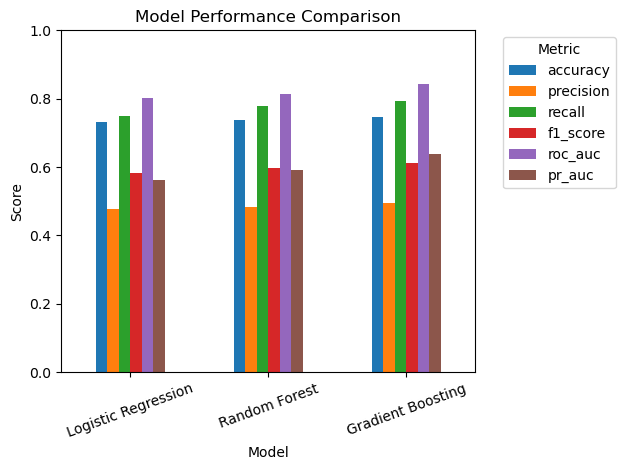

In [79]:
# Cell 40: Plot model comparison

metrics_to_plot = ["accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]

model_comparison_plot = model_comparison.set_index("model")[metrics_to_plot]

display(model_comparison_plot)

plt.figure(figsize=(10, 5))
model_comparison_plot.plot(kind="bar")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [80]:
# Cell 41: Select the best model

best_model_name = "Gradient Boosting"
best_model = gradient_boosting_model

print("Best model selected:", best_model_name)

Best model selected: Gradient Boosting


In [81]:
# Cell 42: Permutation importance for the best model

from sklearn.inspection import permutation_importance

# Use a sample to make permutation importance faster
importance_sample = X_test.copy()
importance_y = y_test.copy()

if len(importance_sample) > 5000:
    importance_sample = importance_sample.sample(n=5000, random_state=42)
    importance_y = y_test.loc[importance_sample.index]

perm_importance = permutation_importance(
    best_model,
    importance_sample,
    importance_y,
    scoring="average_precision",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": features,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
})

importance_df = importance_df.sort_values("importance_mean", ascending=False)

display(importance_df)

,feature,importance_mean,importance_std
0,year,0.314679,0.010350
9,zone_name,0.080452,0.006279
3,Latitude,0.046476,0.003285
4,Longitude,0.045769,0.005674
1,month,0.015851,0.001194
8,state_name,0.010988,0.001886
5,People,0.009746,0.001191
6,Distance km,0.007546,0.001425
2,hurricane_season,0.001010,0.000390
10,Cleanup Type,0.000384,0.000777


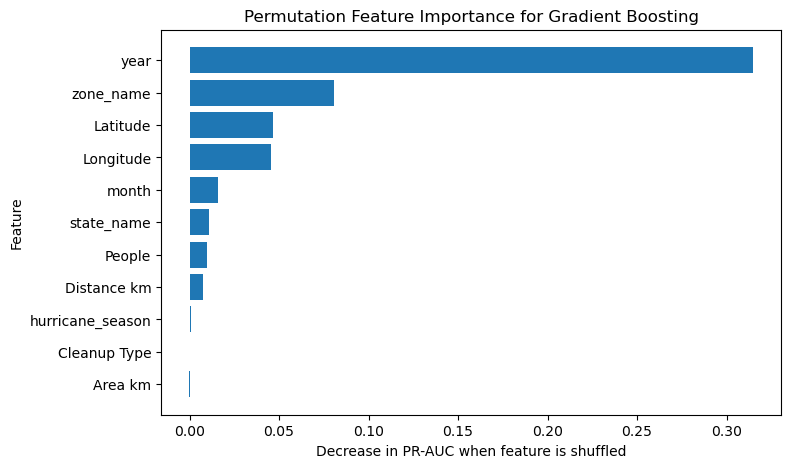

In [82]:
# Cell 43: Plot permutation feature importance

top_importance = importance_df.head(12)

plt.figure(figsize=(8, 5))
plt.barh(top_importance["feature"], top_importance["importance_mean"])
plt.title("Permutation Feature Importance for Gradient Boosting")
plt.xlabel("Decrease in PR-AUC when feature is shuffled")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

### Feature importance interpretation

Permutation feature importance shows how much model performance decreases when each feature is randomly shuffled. A larger decrease means the model relies more heavily on that feature.

The most important feature is `year`, followed by `zone_name`, latitude, and longitude. This suggests that temporal and geographic information are the strongest predictors of high-unusual-debris events.

However, the strong importance of `year` should be interpreted carefully. Because the dataset changed category structure around 2023, the model may partly be learning changes in reporting or data structure rather than only environmental changes.

Geographic variables such as `zone_name`, latitude, and longitude are also important, suggesting that cleanup location plays a major role in predicting high-unusual-debris events. Variables such as `hurricane_season`, `Cleanup Type`, and `Area km` have very low importance in this version of the model.

In [83]:
# Cell 44: Robustness check - remove year from features

numeric_features_no_year = [
    "month",
    "hurricane_season",
    "Latitude",
    "Longitude",
    "People",
    "Distance km",
    "Area km"
]

categorical_features_no_year = [
    "state_name",
    "zone_name",
    "Cleanup Type"
]

features_no_year = numeric_features_no_year + categorical_features_no_year

X_no_year = ml_data[features_no_year].copy()
y_no_year = ml_data[target].copy()

print("X_no_year shape:")
print(X_no_year.shape)

print("\nFeatures without year:")
print(features_no_year)

print("\nTarget distribution:")
print(y_no_year.value_counts(normalize=True))

X_no_year shape:
(131909, 10)

Features without year:
['month', 'hurricane_season', 'Latitude', 'Longitude', 'People', 'Distance km', 'Area km', 'state_name', 'zone_name', 'Cleanup Type']

Target distribution:
high_unusual_event
0    0.749721
1    0.250279
Name: proportion, dtype: float64


In [84]:
# Cell 45: Train-test split for no-year model

from sklearn.model_selection import train_test_split

X_train_no_year, X_test_no_year, y_train_no_year, y_test_no_year = train_test_split(
    X_no_year,
    y_no_year,
    test_size=0.20,
    random_state=42,
    stratify=y_no_year
)

print("Training set size:")
print(X_train_no_year.shape)

print("\nTest set size:")
print(X_test_no_year.shape)

print("\nTraining target distribution:")
print(y_train_no_year.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test_no_year.value_counts(normalize=True))

Training set size:
(105527, 10)

Test set size:
(26382, 10)

Training target distribution:
high_unusual_event
0    0.749723
1    0.250277
Name: proportion, dtype: float64

Test target distribution:
high_unusual_event
0    0.749716
1    0.250284
Name: proportion, dtype: float64


In [85]:
# Cell 46: Build preprocessing pipeline for no-year model

numeric_transformer_no_year = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    categorical_transformer_no_year = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
except TypeError:
    categorical_transformer_no_year = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
    ])

preprocessor_no_year = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer_no_year, numeric_features_no_year),
        ("categorical", categorical_transformer_no_year, categorical_features_no_year)
    ]
)

print("No-year preprocessor created successfully.")

No-year preprocessor created successfully.


In [86]:
# Cell 47: Train Gradient Boosting model without year

gradient_boosting_no_year = Pipeline(steps=[
    ("preprocessor", preprocessor_no_year),
    ("model", HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        class_weight="balanced",
        random_state=42
    ))
])

gradient_boosting_no_year.fit(X_train_no_year, y_train_no_year)

print("Gradient Boosting no-year model trained successfully.")

Gradient Boosting no-year model trained successfully.


In [87]:
# Cell 48: Evaluate Gradient Boosting model without year

gradient_boosting_no_year_results = evaluate_model(
    "Gradient Boosting No Year",
    gradient_boosting_no_year,
    X_test_no_year,
    y_test_no_year
)

Model: Gradient Boosting No Year
Accuracy: 0.6627245849442802
Precision: 0.3955583871848548
Recall: 0.6581856731788581
F1-score: 0.4941444002274019
ROC-AUC: 0.7298624892139775
PR-AUC: 0.5094320892752181

Confusion matrix:
[[13138  6641]
 [ 2257  4346]]

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.66      0.75     19779
           1       0.40      0.66      0.49      6603

    accuracy                           0.66     26382
   macro avg       0.62      0.66      0.62     26382
weighted avg       0.74      0.66      0.68     26382



In [88]:
# Cell 49: Compare original Gradient Boosting and no-year Gradient Boosting

robustness_comparison = pd.DataFrame([
    gradient_boosting_results,
    gradient_boosting_no_year_results
])

display(robustness_comparison)

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Gradient Boosting,0.746380,0.495839,0.794033,0.610467,0.841557,0.637561
1,Gradient Boosting No Year,0.662725,0.395558,0.658186,0.494144,0.729862,0.509432


### Robustness check: removing year

Because `year` was the most important feature in the original Gradient Boosting model, I ran a robustness check by removing `year` from the feature set.

The model performance decreases after removing `year`, which shows that year carries a large amount of predictive information. This may reflect real temporal changes, but it may also reflect changes in reporting, data collection, or item category definitions over time.

However, the no-year model still performs better than random prediction, with a ROC-AUC of about 0.73 and a PR-AUC of about 0.51. This suggests that geographic and cleanup-level features still contain meaningful predictive signal beyond year.

Therefore, the original model is the best-performing model, but its results should be interpreted carefully because part of its predictive power may come from temporal or reporting-related changes.

In [89]:
# Cell 50: Permutation feature importance for no-year Gradient Boosting model

from sklearn.inspection import permutation_importance

# Use a sample to make permutation importance faster
importance_sample_no_year = X_test_no_year.copy()
importance_y_no_year = y_test_no_year.copy()

if len(importance_sample_no_year) > 5000:
    importance_sample_no_year = importance_sample_no_year.sample(n=5000, random_state=42)
    importance_y_no_year = y_test_no_year.loc[importance_sample_no_year.index]

perm_importance_no_year = permutation_importance(
    gradient_boosting_no_year,
    importance_sample_no_year,
    importance_y_no_year,
    scoring="average_precision",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_no_year_df = pd.DataFrame({
    "feature": features_no_year,
    "importance_mean": perm_importance_no_year.importances_mean,
    "importance_std": perm_importance_no_year.importances_std
})

importance_no_year_df = importance_no_year_df.sort_values(
    "importance_mean",
    ascending=False
)

display(importance_no_year_df)

,feature,importance_mean,importance_std
8,zone_name,0.120056,0.007880
5,Distance km,0.074351,0.006273
2,Latitude,0.037201,0.004785
3,Longitude,0.034168,0.003941
0,month,0.026569,0.003345
4,People,0.024361,0.000954
7,state_name,0.017554,0.001184
9,Cleanup Type,0.001574,0.000521
6,Area km,0.000728,0.000866
1,hurricane_season,0.000397,0.000213


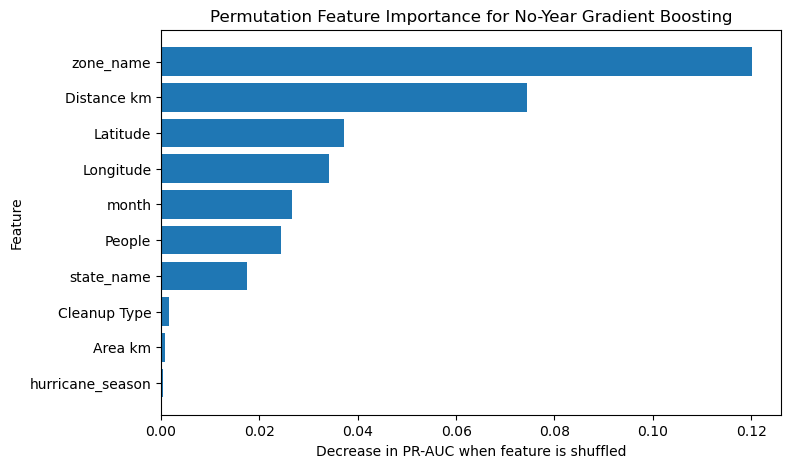

In [90]:
# Cell 51: Plot permutation feature importance for no-year model

top_importance_no_year = importance_no_year_df.head(12)

plt.figure(figsize=(8, 5))
plt.barh(
    top_importance_no_year["feature"],
    top_importance_no_year["importance_mean"]
)
plt.title("Permutation Feature Importance for No-Year Gradient Boosting")
plt.xlabel("Decrease in PR-AUC when feature is shuffled")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

In [91]:
# Cell 52: Save robustness comparison and no-year feature importance

robustness_comparison.to_csv("robustness_comparison_no_year.csv", index=False)
importance_no_year_df.to_csv("feature_importance_no_year.csv", index=False)

print("Robustness comparison and no-year feature importance saved successfully.")

Robustness comparison and no-year feature importance saved successfully.


### No-year feature importance

After removing `year`, the most important predictor is `zone_name`, followed by `Distance km`, latitude, longitude, month, and number of people.

This suggests that the model still captures meaningful geographic and cleanup-level patterns even when year is excluded. Location appears to be especially important, since `zone_name`, latitude, longitude, and state all contribute to prediction.

However, the no-year model performs worse than the original Gradient Boosting model, which confirms that year carries a large amount of predictive information. This may reflect real temporal changes, but it may also reflect changes in reporting or item category definitions over time.

Overall, this robustness check makes the interpretation more careful: the original model performs best, but geographic and cleanup-level variables still matter beyond year.

In [92]:
# Cell 53: Final project summary

print("Final Project Summary")
print("-" * 60)

print("Dataset:")
print("Number of modeling observations:", len(ml_data))
print("Target variable:", target)
print("Positive class: high_unusual_event = 1")

print("\nTarget distribution:")
print(ml_data[target].value_counts(normalize=True))

print("\nBest model:")
print(best_model_name)

print("\nBest model performance:")
best_model_row = model_comparison[model_comparison["model"] == best_model_name]
display(best_model_row)

print("\nRobustness check:")
display(robustness_comparison)

print("\nOriginal Gradient Boosting top features:")
display(importance_df.head(10))

print("\nNo-year Gradient Boosting top features:")
display(importance_no_year_df.head(10))

Final Project Summary
------------------------------------------------------------
Dataset:
Number of modeling observations: 131909
Target variable: high_unusual_event
Positive class: high_unusual_event = 1

Target distribution:
high_unusual_event
0    0.749721
1    0.250279
Name: proportion, dtype: float64

Best model:
Gradient Boosting

Best model performance:


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
2,Gradient Boosting,0.74638,0.495839,0.794033,0.610467,0.841557,0.637561



Robustness check:


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Gradient Boosting,0.746380,0.495839,0.794033,0.610467,0.841557,0.637561
1,Gradient Boosting No Year,0.662725,0.395558,0.658186,0.494144,0.729862,0.509432



Original Gradient Boosting top features:


,feature,importance_mean,importance_std
0,year,0.314679,0.010350
9,zone_name,0.080452,0.006279
3,Latitude,0.046476,0.003285
4,Longitude,0.045769,0.005674
1,month,0.015851,0.001194
8,state_name,0.010988,0.001886
5,People,0.009746,0.001191
6,Distance km,0.007546,0.001425
2,hurricane_season,0.001010,0.000390
10,Cleanup Type,0.000384,0.000777



No-year Gradient Boosting top features:


,feature,importance_mean,importance_std
8,zone_name,0.120056,0.007880
5,Distance km,0.074351,0.006273
2,Latitude,0.037201,0.004785
3,Longitude,0.034168,0.003941
0,month,0.026569,0.003345
4,People,0.024361,0.000954
7,state_name,0.017554,0.001184
9,Cleanup Type,0.001574,0.000521
6,Area km,0.000728,0.000866
1,hurricane_season,0.000397,0.000213


In [93]:
# Cell 54: Save final result tables

model_comparison.to_csv("final_model_comparison.csv", index=False)
importance_df.to_csv("final_feature_importance_gradient_boosting.csv", index=False)
robustness_comparison.to_csv("final_robustness_comparison_no_year.csv", index=False)
importance_no_year_df.to_csv("final_feature_importance_no_year.csv", index=False)

print("Final result tables saved successfully.")

Final result tables saved successfully.


In [94]:
# Cell 55: Save the best trained model

import joblib

joblib.dump(best_model, "best_gradient_boosting_model.pkl")

print("Best model saved successfully.")

Best model saved successfully.


The best-performing model is Gradient Boosting, with a ROC-AUC of about 0.84 and a PR-AUC of about 0.64. It outperforms Logistic Regression and Random Forest across all major evaluation metrics.

The model identifies about 79% of true high-unusual-debris events in the test set, suggesting that machine learning can meaningfully predict which cleanup events are more likely to have unusually high shares of nonstandard debris.

Feature importance shows that year is the strongest predictor, but this should be interpreted carefully because the dataset changed category structure over time. After removing year, the model still performs above random prediction, and location-related features such as zone name, latitude, longitude, and state remain important.

Overall, the results suggest that temporal and geographic patterns are strongly associated with high-unusual-debris events, while broad hurricane season alone is not a strong predictor in this version of the dataset.

In [95]:
# Create the 2023–2025 dataset and reconstruct the target

# Keep only complete years with the newer category structure
model_base_2325 = ml_data[
    (ml_data["year"] >= 2023)
    & (ml_data["year"] <= 2025)
    & (ml_data["Total Items Collected"] > 0)
    & (ml_data["Cleanup Date"].notna())
].copy()

# Recalculate the cutoff using only 2023–2025 observations
cutoff_2325 = model_base_2325["unusual_share"].quantile(0.75)

# Recreate the target variable for the restricted period
target_2325 = "high_unusual_event_2325"

model_base_2325[target_2325] = (
    model_base_2325["unusual_share"] >= cutoff_2325
).astype(int)

print("2023–2025 model base shape:")
print(model_base_2325.shape)

print("\nCutoff for 2023–2025 high-unusual event:")
print(cutoff_2325)

print("\nTarget counts:")
print(model_base_2325[target_2325].value_counts())

print("\nTarget proportions:")
print(model_base_2325[target_2325].value_counts(normalize=True))

print("\nRows by year:")
print(model_base_2325.groupby("year").size())

2023–2025 model base shape:
(40646, 20)

Cutoff for 2023–2025 high-unusual event:
0.1851851851851851

Target counts:
high_unusual_event_2325
0    30464
1    10182
Name: count, dtype: int64

Target proportions:
high_unusual_event_2325
0    0.749496
1    0.250504
Name: proportion, dtype: float64

Rows by year:
year
2023    14415
2024    14803
2025    11428
dtype: int64


## Main Clean Model: 2023–2025 Only

Because the item category structure changed over time and 2026 is only a partial year, I build a cleaner main model using only 2023–2025 data.

For this subset, the target variable is reconstructed using the top 25% of `unusual_share` within 2023–2025 only. This makes the target definition internally consistent for the newer-schema period.

In [96]:
# Cell 56: Create 2023-2025 only dataset and reconstruct target

# Keep only complete years with the newer category structure
model_base_2325 = ml_data[
    (ml_data["year"] >= 2023) &
    (ml_data["year"] <= 2025) &
    (ml_data["Total Items Collected"] > 0) &
    (ml_data["Cleanup Date"].notna())
].copy()

# Recalculate cutoff using only 2023-2025 data
cutoff_2325 = model_base_2325["unusual_share"].quantile(0.75)

# Recreate target variable for this subset
target_2325 = "high_unusual_event_2325"

model_base_2325[target_2325] = (
    model_base_2325["unusual_share"] >= cutoff_2325
).astype(int)

print("2023-2025 model base shape:")
print(model_base_2325.shape)

print("\nCutoff for 2023-2025 high unusual event:")
print(cutoff_2325)

print("\nTarget counts:")
print(model_base_2325[target_2325].value_counts())

print("\nTarget proportions:")
print(model_base_2325[target_2325].value_counts(normalize=True))

print("\nRows by year:")
print(model_base_2325.groupby("year").size())

2023-2025 model base shape:
(40646, 20)

Cutoff for 2023-2025 high unusual event:
0.1851851851851851

Target counts:
high_unusual_event_2325
0    30464
1    10182
Name: count, dtype: int64

Target proportions:
high_unusual_event_2325
0    0.749496
1    0.250504
Name: proportion, dtype: float64

Rows by year:
year
2023    14415
2024    14803
2025    11428
dtype: int64


In [97]:
# Cell 57: Select features for 2023-2025 model

numeric_features_2325 = [
    "year",
    "month",
    "hurricane_season",
    "Latitude",
    "Longitude",
    "People",
    "Distance km",
    "Area km"
]

categorical_features_2325 = [
    "state_name",
    "zone_name",
    "Cleanup Type"
]

features_2325 = numeric_features_2325 + categorical_features_2325

X_2325 = model_base_2325[features_2325].copy()
y_2325 = model_base_2325[target_2325].copy()

print("X_2325 shape:")
print(X_2325.shape)

print("\ny_2325 shape:")
print(y_2325.shape)

print("\nMissing rate in features:")
print(X_2325.isna().mean().sort_values(ascending=False))

print("\nTarget distribution:")
print(y_2325.value_counts(normalize=True))

X_2325 shape:
(40646, 11)

y_2325 shape:
(40646,)

Missing rate in features:
state_name          0.000344
zone_name           0.000320
Distance km         0.000049
year                0.000000
month               0.000000
hurricane_season    0.000000
Latitude            0.000000
Longitude           0.000000
People              0.000000
Area km             0.000000
Cleanup Type        0.000000
dtype: float64

Target distribution:
high_unusual_event_2325
0    0.749496
1    0.250504
Name: proportion, dtype: float64


In [98]:
# Cell 58: Train-test split for 2023-2025 model

from sklearn.model_selection import train_test_split

X_train_2325, X_test_2325, y_train_2325, y_test_2325 = train_test_split(
    X_2325,
    y_2325,
    test_size=0.20,
    random_state=42,
    stratify=y_2325
)

print("Training set size:")
print(X_train_2325.shape)

print("\nTest set size:")
print(X_test_2325.shape)

print("\nTraining target distribution:")
print(y_train_2325.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test_2325.value_counts(normalize=True))

Training set size:
(32516, 11)

Test set size:
(8130, 11)

Training target distribution:
high_unusual_event_2325
0    0.749508
1    0.250492
Name: proportion, dtype: float64

Test target distribution:
high_unusual_event_2325
0    0.749446
1    0.250554
Name: proportion, dtype: float64


In [99]:
# Cell 59: Build preprocessing pipeline for 2023-2025 model

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer_2325 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    categorical_transformer_2325 = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ])
except TypeError:
    categorical_transformer_2325 = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=True))
    ])

preprocessor_2325 = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer_2325, numeric_features_2325),
        ("categorical", categorical_transformer_2325, categorical_features_2325)
    ]
)

print("2023-2025 preprocessor created successfully.")

2023-2025 preprocessor created successfully.


In [100]:
# Cell 60: Train and evaluate Logistic Regression for 2023-2025

from sklearn.linear_model import LogisticRegression

logistic_model_2325 = Pipeline(steps=[
    ("preprocessor", preprocessor_2325),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model_2325.fit(X_train_2325, y_train_2325)

logistic_results_2325 = evaluate_model(
    "Logistic Regression 2023-2025",
    logistic_model_2325,
    X_test_2325,
    y_test_2325
)

Model: Logistic Regression 2023-2025
Accuracy: 0.6682656826568266
Precision: 0.39327296248382926
Recall: 0.5969563082965145
F1-score: 0.47416650419185025
ROC-AUC: 0.7100098610628693
PR-AUC: 0.4652152266859733

Confusion matrix:
[[4217 1876]
 [ 821 1216]]

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.69      0.76      6093
           1       0.39      0.60      0.47      2037

    accuracy                           0.67      8130
   macro avg       0.62      0.64      0.62      8130
weighted avg       0.73      0.67      0.69      8130



In [101]:
# Cell 61: Train and evaluate Random Forest for 2023-2025

from sklearn.ensemble import RandomForestClassifier

random_forest_model_2325 = Pipeline(steps=[
    ("preprocessor", preprocessor_2325),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model_2325.fit(X_train_2325, y_train_2325)

random_forest_results_2325 = evaluate_model(
    "Random Forest 2023-2025",
    random_forest_model_2325,
    X_test_2325,
    y_test_2325
)

Model: Random Forest 2023-2025
Accuracy: 0.6675276752767527
Precision: 0.39515113350125947
Recall: 0.6161021109474718
F1-score: 0.48148858622674084
ROC-AUC: 0.724678584863756
PR-AUC: 0.4864419310297987

Confusion matrix:
[[4172 1921]
 [ 782 1255]]

Classification report:
              precision    recall  f1-score   support

           0       0.84      0.68      0.76      6093
           1       0.40      0.62      0.48      2037

    accuracy                           0.67      8130
   macro avg       0.62      0.65      0.62      8130
weighted avg       0.73      0.67      0.69      8130



In [102]:
# Cell 62A: Dense preprocessor for 2023-2025 Gradient Boosting

numeric_transformer_2325_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    categorical_transformer_2325_dense = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
except TypeError:
    categorical_transformer_2325_dense = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
    ])

preprocessor_2325_dense = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer_2325_dense, numeric_features_2325),
        ("categorical", categorical_transformer_2325_dense, categorical_features_2325)
    ]
)

print("Dense 2023-2025 preprocessor created successfully.")

Dense 2023-2025 preprocessor created successfully.


In [103]:
# Cell 62B: Train and evaluate Gradient Boosting for 2023-2025

from sklearn.ensemble import HistGradientBoostingClassifier

gradient_boosting_model_2325 = Pipeline(steps=[
    ("preprocessor", preprocessor_2325_dense),
    ("model", HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        class_weight="balanced",
        random_state=42
    ))
])

gradient_boosting_model_2325.fit(X_train_2325, y_train_2325)

gradient_boosting_results_2325 = evaluate_model(
    "Gradient Boosting 2023-2025",
    gradient_boosting_model_2325,
    X_test_2325,
    y_test_2325
)

Model: Gradient Boosting 2023-2025
Accuracy: 0.7028290282902829
Precision: 0.435478379298604
Recall: 0.6278841433480609
F1-score: 0.5142742259750703
ROC-AUC: 0.7521929564826518
PR-AUC: 0.5474047275175717

Confusion matrix:
[[4435 1658]
 [ 758 1279]]

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.73      0.79      6093
           1       0.44      0.63      0.51      2037

    accuracy                           0.70      8130
   macro avg       0.64      0.68      0.65      8130
weighted avg       0.75      0.70      0.72      8130



In [104]:
# Cell 63: Compare 2023-2025 model performance

model_results_2325 = [
    logistic_results_2325,
    random_forest_results_2325,
    gradient_boosting_results_2325
]

model_comparison_2325 = pd.DataFrame(model_results_2325)

display(model_comparison_2325)

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression 2023-2025,0.668266,0.393273,0.596956,0.474167,0.710010,0.465215
1,Random Forest 2023-2025,0.667528,0.395151,0.616102,0.481489,0.724679,0.486442
2,Gradient Boosting 2023-2025,0.702829,0.435478,0.627884,0.514274,0.752193,0.547405


In [105]:
# Cell 64: Save 2023-2025 model comparison

model_comparison_2325.to_csv("model_comparison_2023_2025.csv", index=False)

print("2023-2025 model comparison saved successfully.")

2023-2025 model comparison saved successfully.


### 2023–2025 clean model comparison

This model uses only 2023–2025 data because these years have a more consistent item category structure and represent complete years. The target variable was reconstructed within this subset using the top 25% of `unusual_share`.

Among the three models, Gradient Boosting performs best, with the highest accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC. Although its performance is lower than the full 2015–2026 model, this result is more conservative and more interpretable because it avoids mixing older and newer category structures.

The clean 2023–2025 Gradient Boosting model achieves a ROC-AUC of about 0.75 and a PR-AUC of about 0.55, suggesting that machine learning can still identify meaningful patterns in high-unusual-debris events using consistent recent data.

In [106]:
# Cell 65: Select best 2023-2025 model

best_model_2325_name = "Gradient Boosting 2023-2025"
best_model_2325 = gradient_boosting_model_2325

print("Best 2023-2025 model selected:", best_model_2325_name)

Best 2023-2025 model selected: Gradient Boosting 2023-2025


In [107]:
# Cell 66: Permutation feature importance for 2023-2025 Gradient Boosting

from sklearn.inspection import permutation_importance

importance_sample_2325 = X_test_2325.copy()
importance_y_2325 = y_test_2325.copy()

if len(importance_sample_2325) > 5000:
    importance_sample_2325 = importance_sample_2325.sample(n=5000, random_state=42)
    importance_y_2325 = y_test_2325.loc[importance_sample_2325.index]

perm_importance_2325 = permutation_importance(
    best_model_2325,
    importance_sample_2325,
    importance_y_2325,
    scoring="average_precision",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_2325_df = pd.DataFrame({
    "feature": features_2325,
    "importance_mean": perm_importance_2325.importances_mean,
    "importance_std": perm_importance_2325.importances_std
})

importance_2325_df = importance_2325_df.sort_values(
    "importance_mean",
    ascending=False
)

display(importance_2325_df)

,feature,importance_mean,importance_std
9,zone_name,0.155649,0.005016
4,Longitude,0.089101,0.005089
3,Latitude,0.083084,0.001764
1,month,0.028575,0.004175
0,year,0.017662,0.002113
8,state_name,0.016892,0.004585
5,People,0.016822,0.000727
6,Distance km,0.015725,0.003537
10,Cleanup Type,0.001942,0.000574
7,Area km,0.000584,0.000448


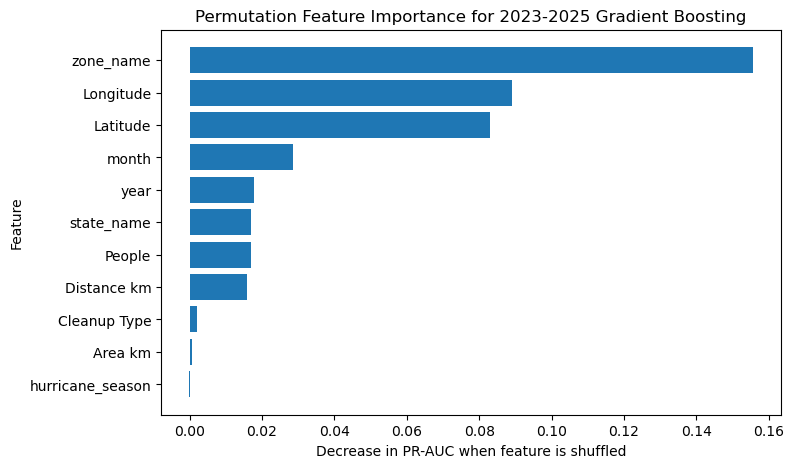

In [108]:
# Cell 67: Plot permutation feature importance for 2023-2025 model

top_importance_2325 = importance_2325_df.head(12)

plt.figure(figsize=(8, 5))
plt.barh(
    top_importance_2325["feature"],
    top_importance_2325["importance_mean"]
)
plt.title("Permutation Feature Importance for 2023-2025 Gradient Boosting")
plt.xlabel("Decrease in PR-AUC when feature is shuffled")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

In [109]:
# Cell 68: Save 2023-2025 final outputs

model_comparison_2325.to_csv("final_model_comparison_2023_2025.csv", index=False)
importance_2325_df.to_csv("final_feature_importance_2023_2025.csv", index=False)

print("2023-2025 final outputs saved successfully.")

2023-2025 final outputs saved successfully.


### 2023–2025 feature importance

Permutation feature importance shows that `zone_name` is the most important predictor in the 2023–2025 clean model, followed by longitude, latitude, month, year, state, people, and distance cleaned.

This suggests that geographic location is the strongest source of predictive information. The importance of `zone_name`, longitude, latitude, and state indicates that high-unusual-debris events are not evenly distributed across locations.

Month also has predictive value, suggesting some seasonal variation. In contrast, the broad `hurricane_season` variable has almost no importance, meaning that simply marking June to November as hurricane season is not enough to identify high-unusual-debris events.

Compared with the full 2015–2026 model, `year` is much less dominant in the 2023–2025 clean model. This makes the 2023–2025 model more interpretable because it relies more on geographic and cleanup-level patterns rather than broad temporal or reporting changes.

In [110]:
# Cell 69: Save the best 2023-2025 model

import joblib

best_model_2325 = gradient_boosting_model_2325

joblib.dump(best_model_2325, "best_gradient_boosting_model_2023_2025.pkl")

print("Best 2023-2025 Gradient Boosting model saved successfully.")

Best 2023-2025 Gradient Boosting model saved successfully.


Final Clean Model Summary: 2023-2025
------------------------------------------------------------
Dataset:
Years used: 2023-2025
Number of observations: 40646
Target variable: high_unusual_event_2325
Positive class: high unusual debris event

Target distribution:
high_unusual_event_2325
0    0.749496
1    0.250504
Name: proportion, dtype: float64

Model comparison:


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression 2023-2025,0.668266,0.393273,0.596956,0.474167,0.710010,0.465215
1,Random Forest 2023-2025,0.667528,0.395151,0.616102,0.481489,0.724679,0.486442
2,Gradient Boosting 2023-2025,0.702829,0.435478,0.627884,0.514274,0.752193,0.547405



Best model:
Gradient Boosting 2023-2025

Top feature importance:


,feature,importance_mean,importance_std
9,zone_name,0.155649,0.005016
4,Longitude,0.089101,0.005089
3,Latitude,0.083084,0.001764
1,month,0.028575,0.004175
0,year,0.017662,0.002113
8,state_name,0.016892,0.004585
5,People,0.016822,0.000727
6,Distance km,0.015725,0.003537
10,Cleanup Type,0.001942,0.000574
7,Area km,0.000584,0.000448


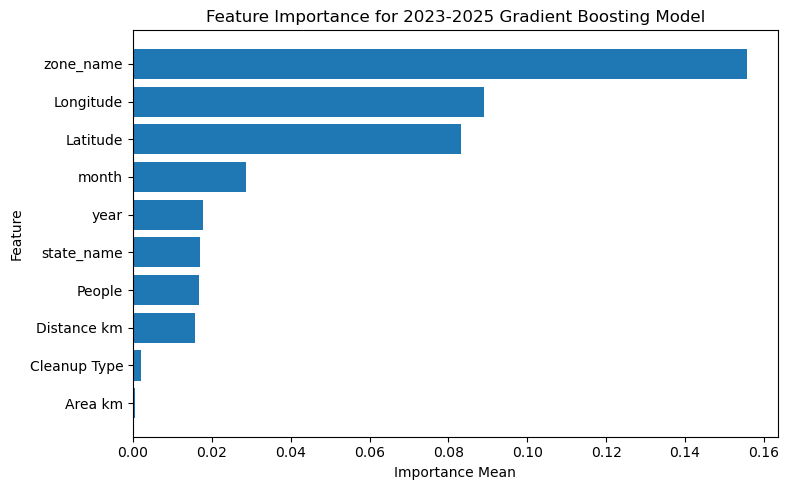

In [111]:
# Cell 70: Final summary for 2023-2025 clean model

print("Final Clean Model Summary: 2023-2025")
print("-" * 60)

print("Dataset:")
print("Years used: 2023-2025")
print("Number of observations:", len(model_base_2325))
print("Target variable:", target_2325)
print("Positive class: high unusual debris event")

print("\nTarget distribution:")
print(model_base_2325[target_2325].value_counts(normalize=True))

print("\nModel comparison:")
display(model_comparison_2325)

print("\nBest model:")
print("Gradient Boosting 2023-2025")

print("\nTop feature importance:")
display(importance_2325_df.head(10))


top_importance_2325 = importance_2325_df.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_importance_2325["feature"], top_importance_2325["importance_mean"])
plt.title("Feature Importance for 2023-2025 Gradient Boosting Model")
plt.xlabel("Importance Mean")
plt.ylabel("Feature")
plt.gca().invert_yaxis()   # make the most important feature appear at the top
plt.tight_layout()
plt.show()

The final clean model uses 2023–2025 cleanup data because these years have a more consistent item category structure and represent complete years. The target variable was reconstructed within this subset by labeling the top 25% of cleanup events by unusual debris share as high-unusual-debris events.

Among Logistic Regression, Random Forest, and Gradient Boosting, Gradient Boosting performs best. The model achieves a ROC-AUC of about 0.75 and a PR-AUC of about 0.55, suggesting that machine learning can identify meaningful patterns associated with high-unusual-debris cleanup events.

Feature importance shows that geographic variables are the most important predictors. `zone_name`, longitude, latitude, and state are more important than the broad hurricane-season indicator. Month also contributes to prediction, suggesting seasonal variation.

Overall, the results suggest that unusual coastal debris patterns are strongly associated with location and time, while a simple hurricane-season indicator is not sufficient to explain high-unusual-debris events.